# Modelo YOLO para detectar Sudokus

```text
imagen → YOLO → OpenCV → tablero corregido → 81 celdas
```

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.7 MB/s eta 0:00:00


In [3]:
import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
print(
    "GPU:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "No disponible"
)

GPU: Tesla T4


## Rutas

In [5]:
ruta_yolo = (
    "/content/drive/MyDrive/"
    "proyecto_DL/modelo_yolo"
)

ruta_dataset = os.path.join(
    ruta_yolo,
    "dataset_sudoku"
)

ruta_imagenes = os.path.join(
    ruta_yolo,
    "imagenes_prueba"
)

ruta_modelo_drive = os.path.join(
    ruta_yolo,
    "modelo",
    "best.pt"
)

print(os.listdir(ruta_dataset))
print(os.listdir(ruta_imagenes))

['images', 'labels', 'data.yaml']
['sudoku_prueba.jpg']


In [6]:
ruta_yaml = "/content/data_colab.yaml"

contenido_yaml = f"""
path: {ruta_dataset}

train: images/train
val: images/val
test: images/test

names:
  0: sudoku
"""

with open(ruta_yaml, "w") as archivo:
    archivo.write(contenido_yaml)

print(contenido_yaml)


path: /content/drive/MyDrive/proyecto_DL/modelo_yolo/dataset_sudoku

train: images/train
val: images/val
test: images/test

names:
  0: sudoku



## Entrenamiento

In [7]:
modelo = YOLO("yolov8s.pt")

modelo.train(
    data=ruta_yaml,
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/runs_yolo",
    name="sudoku",
    exist_ok=True
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sudoku, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f59241407d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## Evaluación

In [8]:
ruta_best = (
    "/content/runs_yolo/"
    "sudoku/weights/best.pt"
)

modelo = YOLO(ruta_best)

metricas_val = modelo.val(
    data=ruta_yaml,
    split="val",
    device=0
)

metricas_test = modelo.val(
    data=ruta_yaml,
    split="test",
    device=0
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 116.7±223.2 MB/s, size: 671.8 KB)
val: Scanning /content/drive/MyDrive/proyecto_DL/modelo_yolo/dataset_sudoku/labels/val.cache... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 9.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4it/s 1.4s
                   all         21         21      0.998          1      0.995       0.99
Speed: 1.5ms preprocess, 28.2ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 1.9±2.0 MB/s, size: 1246.2 KB)
val: Scanning /content/drive/MyDrive/proyecto_DL/modelo_yolo/dataset_sudoku/l

In [9]:
print("VALIDACIÓN")
print("Precision:", round(metricas_val.box.mp, 4))
print("Recall:", round(metricas_val.box.mr, 4))
print("mAP50:", round(metricas_val.box.map50, 4))
print("mAP50-95:", round(metricas_val.box.map, 4))

print("\nTEST")
print("Precision:", round(metricas_test.box.mp, 4))
print("Recall:", round(metricas_test.box.mr, 4))
print("mAP50:", round(metricas_test.box.map50, 4))
print("mAP50-95:", round(metricas_test.box.map, 4))

VALIDACIÓN
Precision: 0.9977
Recall: 1.0
mAP50: 0.995
mAP50-95: 0.9901

TEST
Precision: 0.9561
Recall: 1.0
mAP50: 0.995
mAP50-95: 0.9728


In [10]:
os.makedirs(
    os.path.dirname(ruta_modelo_drive),
    exist_ok=True
)

shutil.copy(
    ruta_best,
    ruta_modelo_drive
)

print("Modelo guardado en:", ruta_modelo_drive)

Modelo guardado en: /content/drive/MyDrive/proyecto_DL/modelo_yolo/modelo/best.pt


## Procesamiento de la imagen

In [11]:
import cv2
import numpy as np


def procesar_sudoku(imagen, modelo):

    resultado = modelo(
        imagen,
        verbose=False
    )[0]

    if len(resultado.boxes) == 0:
        raise ValueError("No se ha detectado el Sudoku")

    x1, y1, x2, y2 = (
        resultado.boxes.xyxy[0]
        .cpu()
        .numpy()
        .astype(int)
    )

    tablero = imagen[y1:y2, x1:x2]

    gris = cv2.cvtColor(
        tablero,
        cv2.COLOR_BGR2GRAY
    )

    gris = cv2.GaussianBlur(
        gris,
        (5, 5),
        0
    )

    binaria = cv2.adaptiveThreshold(
        gris,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    lineas = cv2.HoughLinesP(
        binaria,
        1,
        np.pi / 180,
        80,
        minLineLength=80,
        maxLineGap=15
    )

    if lineas is None:
        raise ValueError("No se ha detectado la cuadrícula")

    horizontales = []
    verticales = []

    for linea in lineas:

        x1, y1, x2, y2 = linea[0]

        if abs(x2 - x1) > abs(y2 - y1):
            horizontales.append(
                int((y1 + y2) / 2)
            )
        else:
            verticales.append(
                int((x1 + x2) / 2)
            )

    def agrupar(posiciones, distancia=8):

        posiciones = sorted(posiciones)
        grupos = []

        for posicion in posiciones:

            if not grupos:
                grupos.append([posicion])

            elif posicion - np.mean(grupos[-1]) <= distancia:
                grupos[-1].append(posicion)

            else:
                grupos.append([posicion])

        return [
            int(np.mean(grupo))
            for grupo in grupos
        ]

    horizontales = agrupar(horizontales)
    verticales = agrupar(verticales)

    if len(horizontales) < 2 or len(verticales) < 2:
        raise ValueError("No se han detectado los bordes")

    origen = np.float32(
        [
            [verticales[0], horizontales[0]],
            [verticales[-1], horizontales[0]],
            [verticales[-1], horizontales[-1]],
            [verticales[0], horizontales[-1]]
        ]
    )

    destino = np.float32(
        [
            [0, 0],
            [449, 0],
            [449, 449],
            [0, 449]
        ]
    )

    matriz = cv2.getPerspectiveTransform(
        origen,
        destino
    )

    tablero = cv2.warpPerspective(
        tablero,
        matriz,
        (450, 450)
    )

    celdas = []

    for fila in range(9):
        for columna in range(9):

            celda = tablero[
                fila * 50:(fila + 1) * 50,
                columna * 50:(columna + 1) * 50
            ]

            celdas.append(celda)

    return tablero, celdas


In [12]:
nombre_imagen = os.listdir(
    ruta_imagenes
)[0]

ruta_imagen = os.path.join(
    ruta_imagenes,
    nombre_imagen
)

imagen = cv2.imread(
    ruta_imagen
)

tablero, celdas = procesar_sudoku(
    imagen,
    modelo
)

print("Tablero:", tablero.shape)
print("Celdas:", len(celdas))
print("Tamaño:", celdas[0].shape)

Tablero: (450, 450, 3)
Celdas: 81
Tamaño: (50, 50, 3)


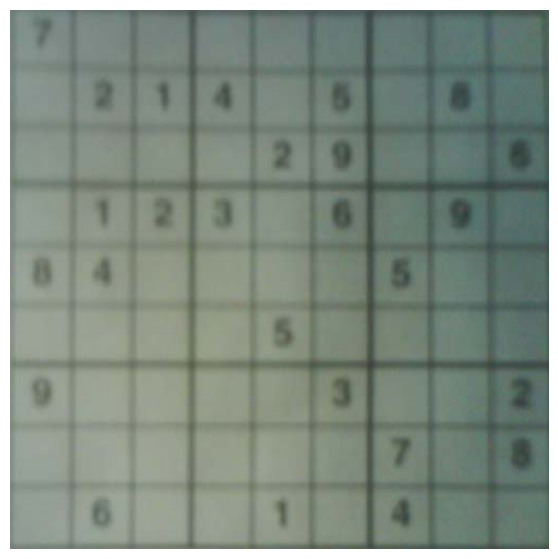

In [13]:
plt.figure(figsize=(7, 7))

plt.imshow(
    cv2.cvtColor(
        tablero,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.show()

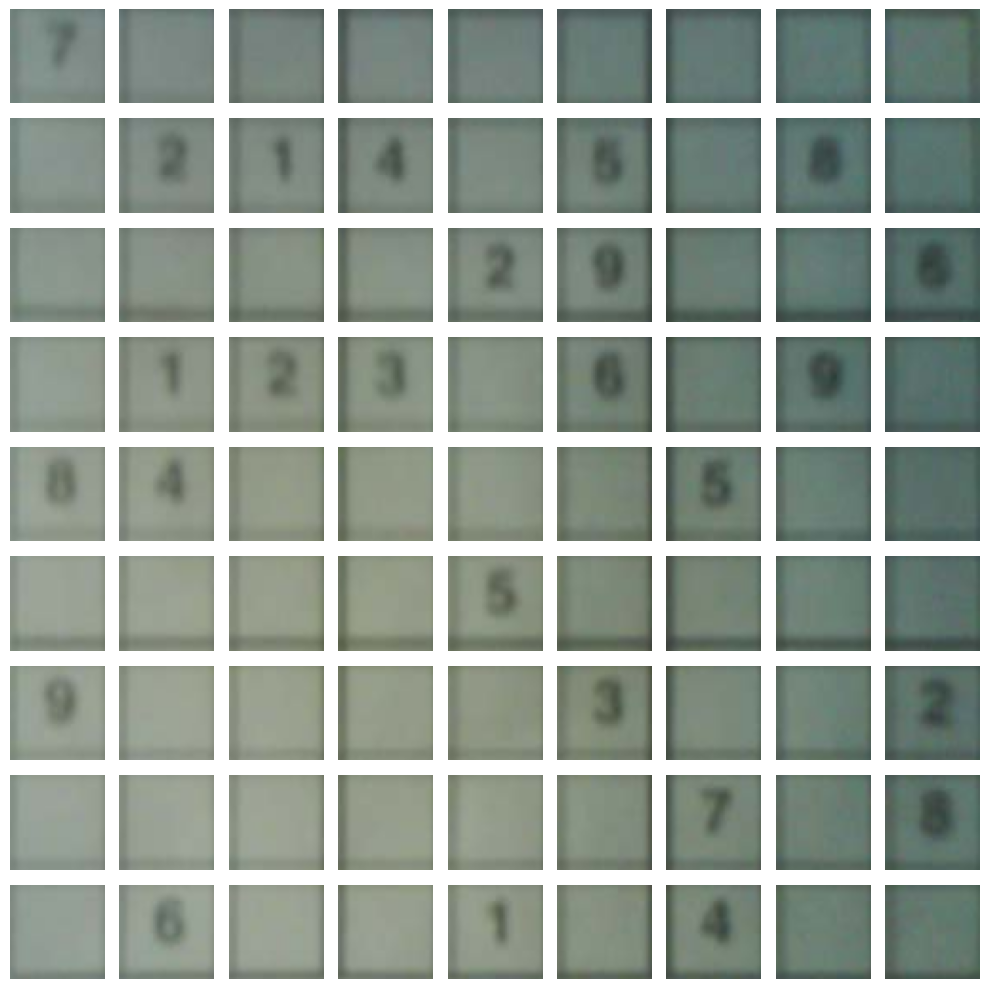

In [14]:
fig, axes = plt.subplots(
    9,
    9,
    figsize=(10, 10)
)

for i, celda in enumerate(celdas):

    fila = i // 9
    columna = i % 9

    axes[fila, columna].imshow(
        cv2.cvtColor(
            celda,
            cv2.COLOR_BGR2RGB
        )
    )

    axes[fila, columna].axis("off")

plt.tight_layout()
plt.show()